<a href="https://colab.research.google.com/github/pnnitish9/MLOps/blob/main/Skill_Gap_Framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Employability Analysis (Research Edition)
This notebook performs end-to-end statistical analysis and machine learning for the **Curriculum–Industry Skill Alignment** dataset.

## Install Packages

In [1]:
!pip -q install pandas numpy scipy statsmodels scikit-learn matplotlib seaborn openpyxl shap xgboost

## Upload Dataset

In [2]:
from google.colab import files
uploaded=files.upload()

Saving CSE_Employability_Dataset_For_Advanced_Colab.csv to CSE_Employability_Dataset_For_Advanced_Colab.csv


## Imports

In [3]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import *
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
df=pd.read_csv(next(iter(uploaded)))
df.head()

,Student_ID,University,Department,Semester,Gender,Age,CGPA,Java,Python,DSA,...,Resume_Score,Coding_Test_Score,Mock_Interview_Score,Curriculum_Coverage,Industry_Skill_Level,Skill_Gap_Score,Placement,Company,Package_LPA,Placement_Probability
0,S0001,University D,CSE-AI,8,Female,24,8.31,1,3,2,...,88,41,80,2.00,2.43,2.57,Yes,Amazon,6.48,0.85
1,S0002,University A,CSE-DS,8,Female,24,6.72,1,2,4,...,52,86,74,2.57,2.00,3.00,Yes,IBM,11.54,0.78
2,S0003,University B,CSE-AI,8,Male,23,6.35,1,1,2,...,67,84,88,2.00,2.29,2.71,Yes,Microsoft,13.22,0.82
3,S0004,University C,IT,8,Female,22,7.17,5,2,3,...,91,69,54,2.71,3.00,2.00,Yes,Accenture,7.47,0.92
4,S0005,University C,CSE-DS,8,Male,22,6.47,2,5,4,...,66,75,100,1.86,3.57,1.43,Yes,Infosys,17.64,0.93


## Encoding

In [4]:
for c in df.select_dtypes(include='object').columns:
    df[c]=LabelEncoder().fit_transform(df[c].astype(str))
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 33 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             1000 non-null   int64  
 1   University             1000 non-null   int64  
 2   Department             1000 non-null   int64  
 3   Semester               1000 non-null   int64  
 4   Gender                 1000 non-null   int64  
 5   Age                    1000 non-null   int64  
 6   CGPA                   1000 non-null   float64
 7   Java                   1000 non-null   int64  
 8   Python                 1000 non-null   int64  
 9   DSA                    1000 non-null   int64  
 10  DBMS                   1000 non-null   int64  
 11  OS                     1000 non-null   int64  
 12  CN                     1000 non-null   int64  
 13  Web_Development        1000 non-null   int64  
 14  SQL                    1000 non-null   int64  
 15  Git  

## Descriptive Statistics

In [5]:
display(df.describe().T)
print(df.skew(numeric_only=True))

,count,mean,std,min,25%,50%,75%,max
Student_ID,1000.0,499.50000,288.819436,0.00,249.75,499.500,749.2500,999.00
University,1000.0,1.43000,1.109203,0.00,0.00,1.000,2.0000,3.00
Department,1000.0,1.51400,1.123863,0.00,1.00,2.000,3.0000,3.00
Semester,1000.0,8.00000,0.000000,8.00,8.00,8.000,8.0000,8.00
Gender,1000.0,0.47500,0.499624,0.00,0.00,0.000,1.0000,1.00
Age,1000.0,21.93000,1.413895,20.00,21.00,22.000,23.0000,24.00
CGPA,1000.0,7.69110,1.254246,5.50,6.58,7.725,8.7600,9.90
Java,1000.0,3.08700,1.399782,1.00,2.00,3.000,4.0000,5.00
Python,1000.0,2.95400,1.414880,1.00,2.00,3.000,4.0000,5.00
DSA,1000.0,3.03700,1.403425,1.00,2.00,3.000,4.0000,5.00


Student_ID               0.000000
University               0.115357
Department              -0.018017
Semester                 0.000000
Gender                   0.100276
Age                      0.034682
CGPA                    -0.022062
Java                    -0.093819
Python                   0.051730
DSA                     -0.054958
DBMS                    -0.032361
OS                      -0.019255
CN                      -0.029532
Web_Development          0.031822
SQL                     -0.017540
Git                      0.015010
Cloud                    0.023341
AI_ML                    0.011378
Communication            0.019402
Aptitude                -0.007581
Teamwork                -0.019584
Internship              -0.072155
Certifications           0.008972
Resume_Score            -0.016360
Coding_Test_Score        0.005727
Mock_Interview_Score    -0.034367
Curriculum_Coverage      0.027133
Industry_Skill_Level     0.014110
Skill_Gap_Score         -0.014110
Placement     

## Missing Values

In [7]:
print(df.isnull().sum())

Student_ID               0
University               0
Department               0
Semester                 0
Gender                   0
Age                      0
CGPA                     0
Java                     0
Python                   0
DSA                      0
DBMS                     0
OS                       0
CN                       0
Web_Development          0
SQL                      0
Git                      0
Cloud                    0
AI_ML                    0
Communication            0
Aptitude                 0
Teamwork                 0
Internship               0
Certifications           0
Resume_Score             0
Coding_Test_Score        0
Mock_Interview_Score     0
Curriculum_Coverage      0
Industry_Skill_Level     0
Skill_Gap_Score          0
Placement                0
Company                  0
Package_LPA              0
Placement_Probability    0
dtype: int64


## Outlier Detection

In [8]:
num=df.select_dtypes(include=np.number)
Q1=num.quantile(.25);Q3=num.quantile(.75);IQR=Q3-Q1
out=((num<(Q1-1.5*IQR))|(num>(Q3+1.5*IQR))).sum()
print(out)

Student_ID                0
University                0
Department                0
Semester                  0
Gender                    0
Age                       0
CGPA                      0
Java                      0
Python                    0
DSA                       0
DBMS                      0
OS                        0
CN                        0
Web_Development           0
SQL                       0
Git                       0
Cloud                     0
AI_ML                     0
Communication             0
Aptitude                  0
Teamwork                  0
Internship                0
Certifications            0
Resume_Score              0
Coding_Test_Score         0
Mock_Interview_Score      0
Curriculum_Coverage       1
Industry_Skill_Level     20
Skill_Gap_Score          20
Placement                25
Company                   0
Package_LPA               0
Placement_Probability     0
dtype: int64


## Normality

In [9]:
for col in ['CGPA','Coding_Test_Score','Resume_Score']:
    print(col,stats.shapiro(df[col].sample(min(500,len(df)),random_state=1)))

CGPA ShapiroResult(statistic=np.float64(0.9572699293357694), pvalue=np.float64(7.407852120569394e-11))
Coding_Test_Score ShapiroResult(statistic=np.float64(0.9575889699826933), pvalue=np.float64(8.335306658092079e-11))
Resume_Score ShapiroResult(statistic=np.float64(0.9468382810944012), pvalue=np.float64(2.0695906316827867e-12))


## Correlation

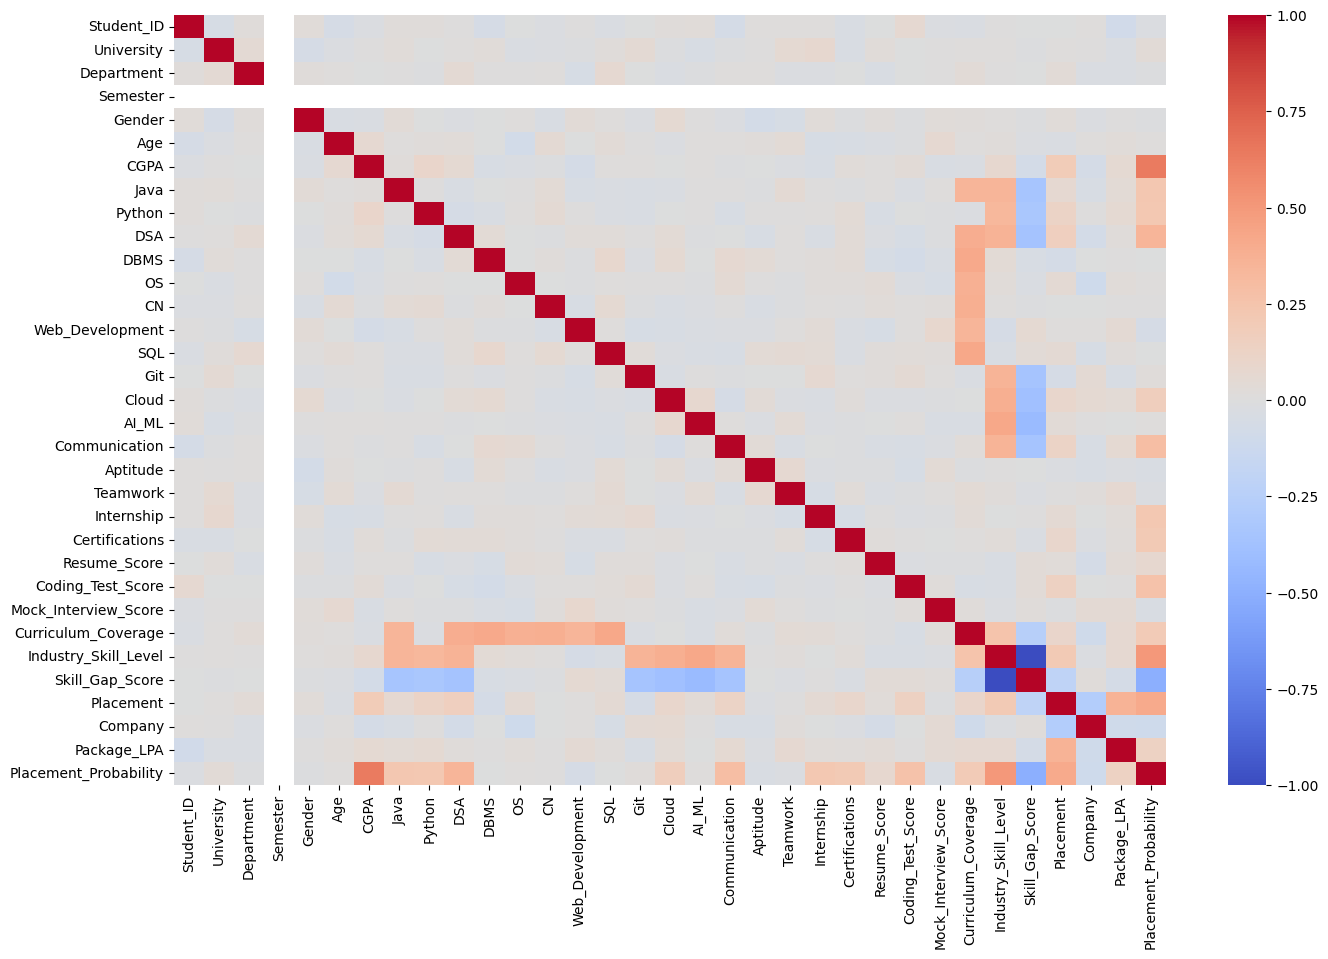

In [10]:
corr=df.corr(numeric_only=True)
plt.figure(figsize=(16,10))
sns.heatmap(corr,cmap='coolwarm')
plt.show()

## Chi Square

In [11]:
tab=pd.crosstab(df['Internship'],df['Placement'])
print(stats.chi2_contingency(tab))

Chi2ContingencyResult(statistic=np.float64(1.9557654412426184), pvalue=np.float64(0.16196692185485095), dof=1, expected_freq=array([[ 12.05, 469.95],
       [ 12.95, 505.05]]))


## T Test

In [12]:
print(stats.ttest_ind(df[df.Placement==1].CGPA,df[df.Placement==0].CGPA))

TtestResult(statistic=np.float64(6.139354505729345), pvalue=np.float64(1.1941617178010073e-09), df=np.float64(998.0))


## ANOVA

In [13]:
m=smf.ols('Coding_Test_Score~C(Department)',data=df).fit()
print(anova_lm(m))

                  df         sum_sq     mean_sq         F    PR(>F)
C(Department)    3.0     269.367921   89.789307  0.286955  0.834846
Residual       996.0  311652.376079  312.903992       NaN       NaN


## Regression

In [14]:
X=df[['CGPA','Java','Python','DSA','Communication','Coding_Test_Score','Resume_Score','Cloud','Certifications']]
X=sm.add_constant(X)
print(sm.OLS(df['Placement_Probability'],X).fit().summary())

                              OLS Regression Results                             
Dep. Variable:     Placement_Probability   R-squared:                       0.841
Model:                               OLS   Adj. R-squared:                  0.839
Method:                    Least Squares   F-statistic:                     580.3
Date:                   Mon, 27 Jul 2026   Prob (F-statistic):               0.00
Time:                           06:08:21   Log-Likelihood:                 1985.4
No. Observations:                   1000   AIC:                            -3951.
Df Residuals:                        990   BIC:                            -3902.
Df Model:                              9                                         
Covariance Type:               nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const   

## Classification

In [15]:
X=df[['CGPA','Java','Python','DSA','Communication','Coding_Test_Score','Cloud','Certifications','Internship']]
y=df['Placement']
Xtr,Xte,Ytr,Yte=train_test_split(X,y,test_size=.2,random_state=42)
models={
'Logistic':LogisticRegression(max_iter=1000),
'DecisionTree':DecisionTreeClassifier(random_state=42),
'RandomForest':RandomForestClassifier(random_state=42),
'SVM':SVC(probability=True)
}
for n,m in models.items():
    m.fit(Xtr,Ytr)
    p=m.predict(Xte)
    print(n,accuracy_score(Yte,p))
    print(confusion_matrix(Yte,p))


Logistic 0.99
[[  4   2]
 [  0 194]]
DecisionTree 0.96
[[  0   6]
 [  2 192]]
RandomForest 0.97
[[  0   6]
 [  0 194]]
SVM 0.97
[[  0   6]
 [  0 194]]


## Decision Tree


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Features
X = df[['CGPA',
        'Java',
        'Python',
        'DSA',
        'Communication',
        'Coding_Test_Score',
        'Cloud',
        'Certifications',
        'Internship']]

# Target
y = df['Placement']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

# Train Decision Tree
dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)

dt.fit(X_train, y_train)

# Predictions
y_pred = dt.predict(X_test)

# Accuracy
print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Accuracy: 96.0 %

Classification Report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.97      0.99      0.98       194

    accuracy                           0.96       200
   macro avg       0.48      0.49      0.49       200
weighted avg       0.94      0.96      0.95       200


Confusion Matrix
[[  0   6]
 [  2 192]]


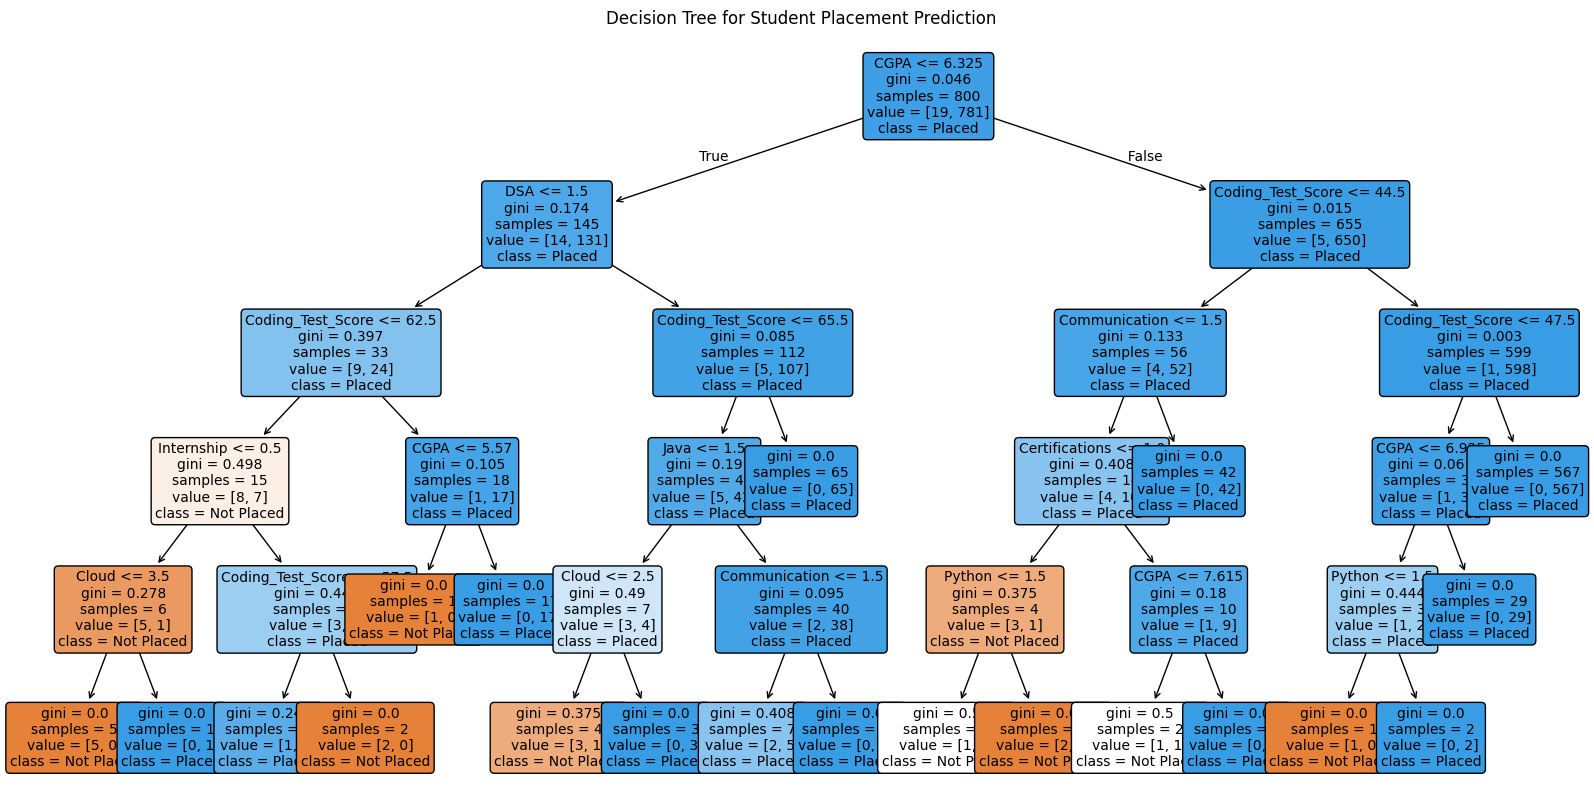

In [17]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["Not Placed", "Placed"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree for Student Placement Prediction")
plt.show()

             Feature  Importance
5  Coding_Test_Score    0.247917
0               CGPA    0.178127
6              Cloud    0.123862
4      Communication    0.091543
3                DSA    0.091369
7     Certifications    0.083176
2             Python    0.063162
8         Internship    0.062013
1               Java    0.058830


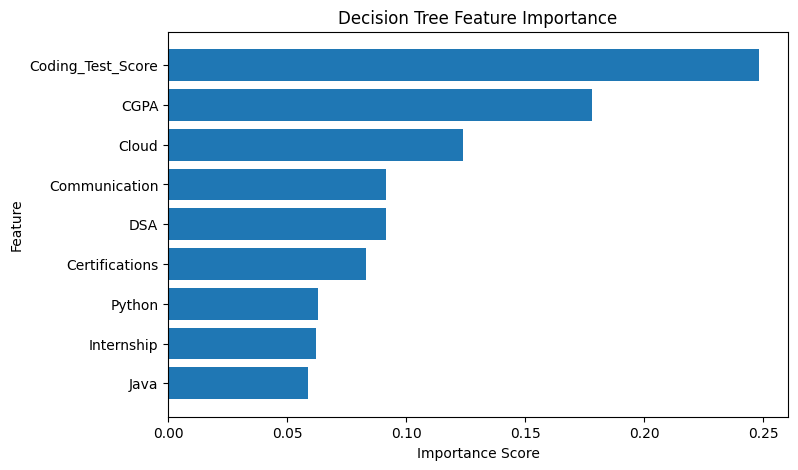

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

plt.figure(figsize=(8,5))
plt.barh(importance["Feature"], importance["Importance"])
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Decision Tree Feature Importance")
plt.gca().invert_yaxis()
plt.show()

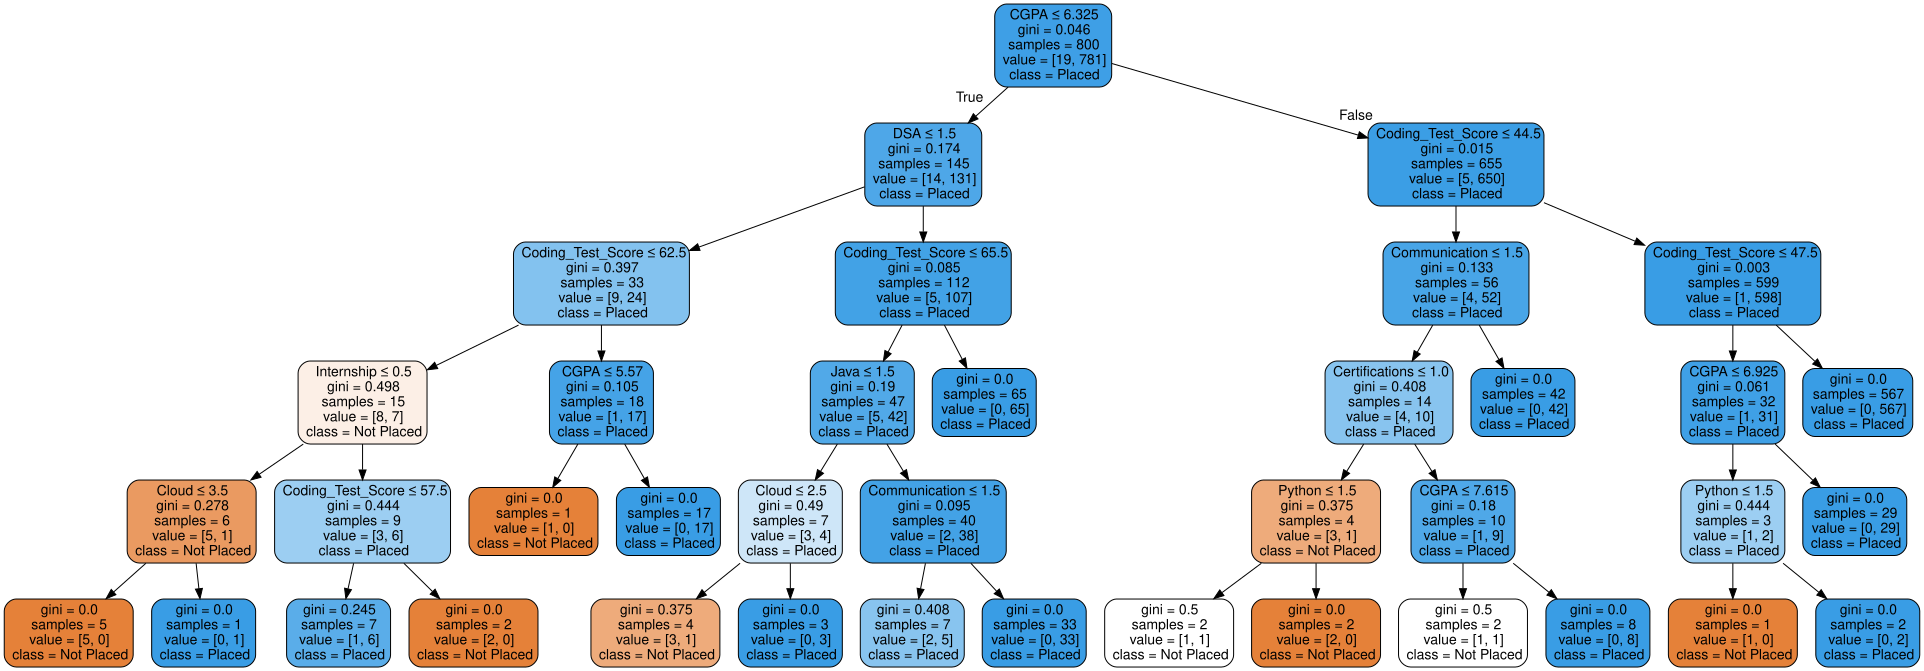

In [19]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    dt,
    out_file=None,
    feature_names=X.columns,
    class_names=["Not Placed", "Placed"],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)

graph.render("Decision_Tree", format="png")

graph

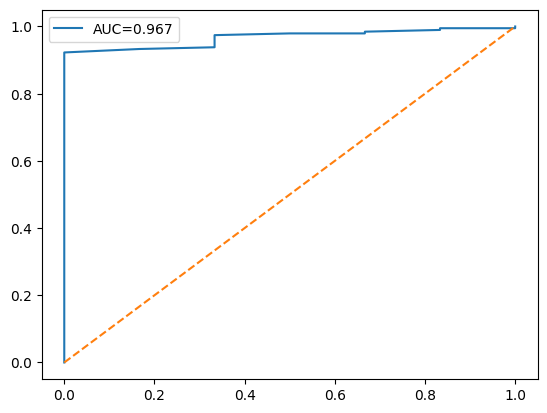

In [20]:
rf=RandomForestClassifier(random_state=42).fit(Xtr,Ytr)
probs=rf.predict_proba(Xte)[:,1]
fpr,tpr,_=roc_curve(Yte,probs)
plt.plot(fpr,tpr,label=f'AUC={auc(fpr,tpr):.3f}')
plt.plot([0,1],[0,1],'--')
plt.legend();plt.show()

## Feature Importance

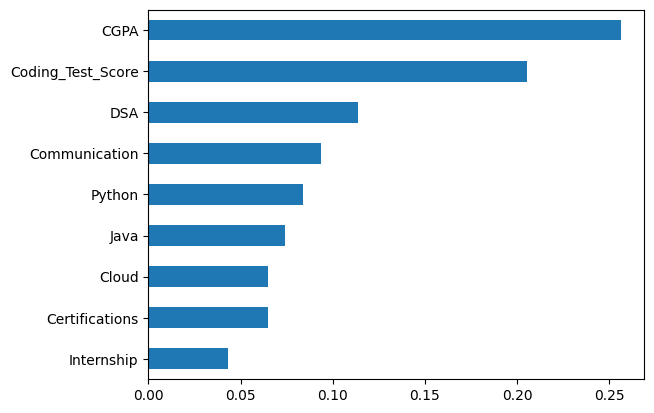

In [21]:
imp=pd.Series(rf.feature_importances_,index=X.columns).sort_values()
imp.plot(kind='barh');plt.show()

## PCA

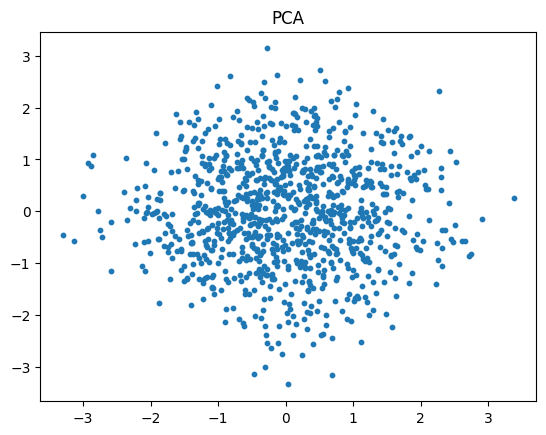

[0.12899288 0.124083  ]


In [22]:
sc=StandardScaler()
Xs=sc.fit_transform(df[X.columns])
p=PCA(n_components=2)
pc=p.fit_transform(Xs)
plt.scatter(pc[:,0],pc[:,1],s=10)
plt.title('PCA')
plt.show()
print(p.explained_variance_ratio_)

## KMeans

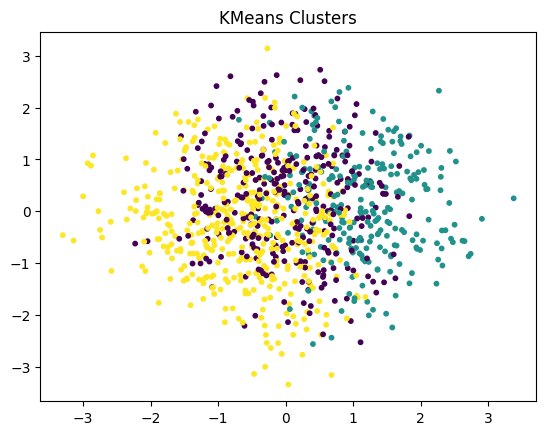

In [23]:
km=KMeans(n_clusters=3,random_state=42,n_init=10)
labels=km.fit_predict(Xs)
plt.scatter(pc[:,0],pc[:,1],c=labels,s=10)
plt.title('KMeans Clusters')
plt.show()

## Dashboard

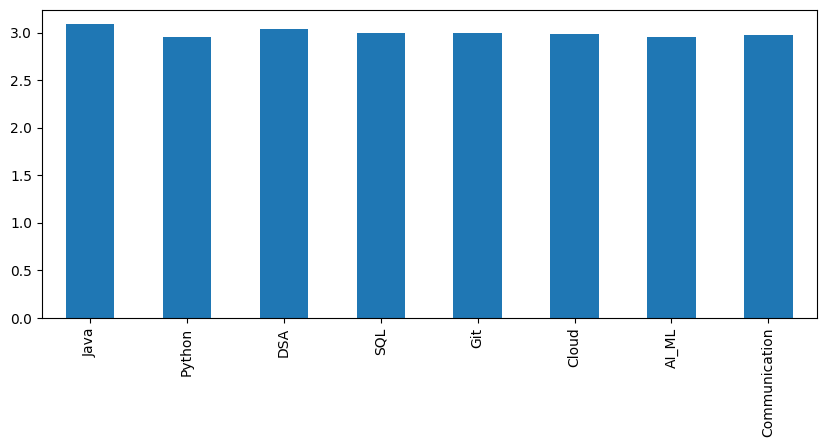

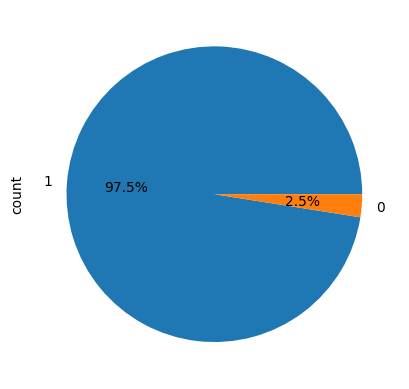

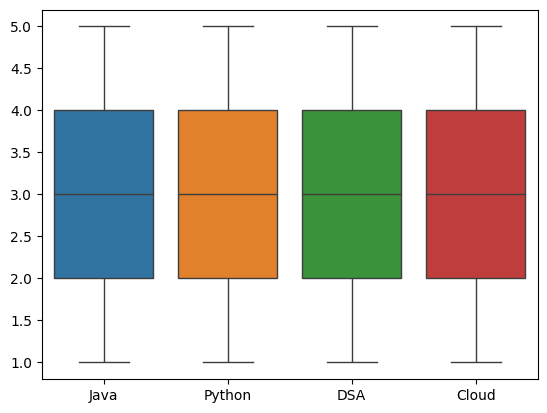

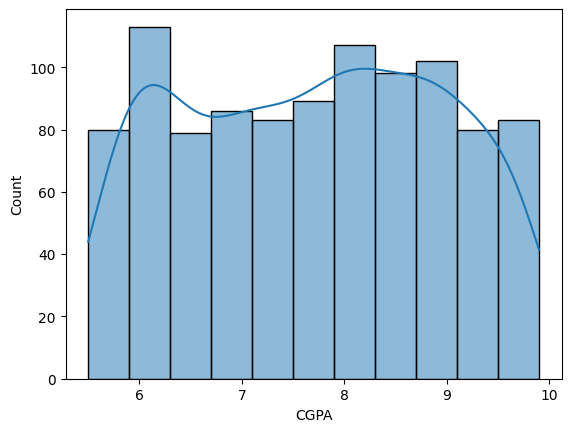

In [24]:
skills=['Java','Python','DSA','SQL','Git','Cloud','AI_ML','Communication']
df[skills].mean().plot.bar(figsize=(10,4));plt.show()
df['Placement'].value_counts().plot.pie(autopct='%1.1f%%');plt.show()
sns.boxplot(data=df[['Java','Python','DSA','Cloud']]);plt.show()
sns.histplot(df['CGPA'],kde=True);plt.show()

## Export

In [25]:
with pd.ExcelWriter('Research_Analysis_Output.xlsx') as w:
    df.describe().T.to_excel(w,sheet_name='Summary')
    corr.to_excel(w,sheet_name='Correlation')
print('Done')

Done
